# CT Scanner Simulator

**Group:**
* Jakub Biernat 160248
* Eryk Masian 160228

**Tomograph Model:**
* **Cone-beam**

**Technologies Used:**
* **Language:** Python
* **Libraries:** numpy, matplotlib, ipywidgets, pydicom

**Functions**
* [Radon Transform](../src/radon_transform.py)
* [Emitter Positioning](../src/emiters.py)
* [Detector Positioning](../src/detectors.py)
* [Bresenham Algorithm]()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import ipywidgets as widgets
from IPython.display import display, clear_output
import pydicom
from pydicom.dataset import FileDataset, FileMetaDataset
from pydicom.uid import UID
import datetime
import os

import sys
sys.path.append(os.path.abspath('..'))

from src.radon_transform import get_sinogram, inverse_radon
from src.bresenham import bresenham
from src.emiters import emitterPos
from src.detectors import detectorsPos
from src.filter import apply_filter
from src.rmse import calculate_rmse

available_images = {
    "CT_ScoutView": "../data/input/CT_ScoutView.jpg",
    "CT_ScoutView-large": "../data/input/CT_ScoutView-large.jpg",
    "Kolo": "../data/input/Kolo.jpg",
    "Kropka": "../data/input/Kropka.jpg",
    "Kwadraty2": "../data/input/Kwadraty2.jpg",
    "Paski2": "../data/input/Paski2.jpg",
    "SADDLE_PE": "../data/input/SADDLE_PE.jpg",
    "SADDLE_PE-large": "../data/input/SADDLE_PE-large.jpg",
    "Shepp_logan": "../data/input/Shepp_logan.jpg"
}

latest_reconstructed_image = None


In [2]:
current_image_name = None
current_image_array = None

image_dropdown = widgets.Dropdown(options=list(available_images.keys()), value="Shepp_logan", description='Obraz:')
preview_output = widgets.Output()

def update_image_preview(change):
    global current_image_name, current_image_array
    with preview_output:
        clear_output(wait=True)
        current_image_name = change.new
        img_path = available_images[current_image_name]

        try:
            img_array = plt.imread(img_path)
            if len(img_array.shape) == 3:
                img_array = np.mean(img_array, axis=2)
            current_image_array = img_array

            plt.figure(figsize=(4, 4))
            plt.imshow(current_image_array, cmap='gray')
            plt.title(f"Wybrano: {current_image_name}")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"Błąd: Nie znaleziono pliku {img_path}")

image_dropdown.observe(update_image_preview, names='value')
display(image_dropdown, preview_output)
update_image_preview({'new': image_dropdown.value})

Dropdown(description='Obraz:', index=8, options=('CT_ScoutView', 'CT_ScoutView-large', 'Kolo', 'Kropka', 'Kwad…

Output()

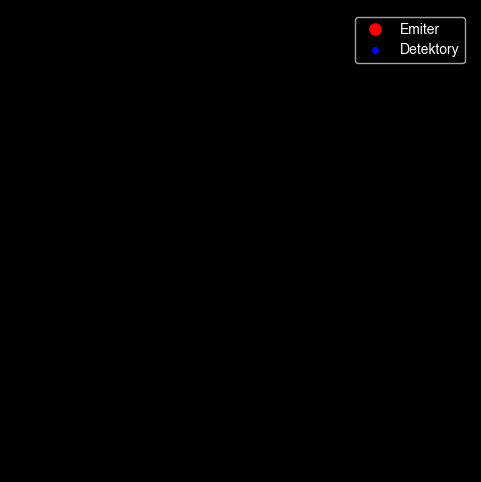

In [3]:
angle_slider = widgets.IntSlider(min=0, max=360, step=5, value=0, description='Kąt obr. (st):')
detectors_slider = widgets.IntSlider(min=10, max=720, step=10, value=180, description='Detektory (n):')
span_slider = widgets.IntSlider(min=45, max=270, step=45, value=180, description='Rozpiętość (st):')

fig, ax = plt.subplots(figsize=(6, 6))
plt.close(fig)

img_plot = ax.imshow(np.zeros((100, 100)), cmap='gray')
rays_collection = LineCollection([], colors='r', alpha=0.1)
ax.add_collection(rays_collection)
emitter_pt, = ax.plot([], [], 'ro', markersize=8, label="Emiter")
detectors_pts, = ax.plot([], [], 'bo', markersize=4, label="Detektory")
ax.legend()
ax.axis('off')

image_loaded = False

ui_box = widgets.VBox([angle_slider, detectors_slider, span_slider])
display(ui_box)

display_handle = display(fig, display_id=True)

def update_geometry(change=None):
    global image_loaded
    if current_image_array is None:
        return

    if not image_loaded:
        img_plot.set_data(current_image_array)
        img_plot.set_extent((-0.5, current_image_array.shape[1]-0.5, current_image_array.shape[0]-0.5, -0.5))
        r = current_image_array.shape[0] * np.sqrt(2) / 2
        center = current_image_array.shape[0] / 2
        ax.set_xlim(center - r - 10, center + r + 10)
        ax.set_ylim(center + r + 10, center - r - 10)
        image_loaded = True

    angle = angle_slider.value
    detectors = detectors_slider.value
    span = span_slider.value

    xe, ye = emitterPos(current_image_array, angle)
    detectors_pos = detectorsPos(current_image_array, angle, detectors, span)

    emitter_pt.set_data([xe], [ye])

    if detectors_pos:
        xd_list, yd_list = zip(*detectors_pos)
        detectors_pts.set_data(xd_list, yd_list)

        segments = [[(xe, ye), (xd, yd)] for xd, yd in detectors_pos]
        rays_collection.set_segments(segments)

    ax.set_title(f"Symulacja wiązki: kąt {angle}°, detektory: {detectors}, rozpiętość: {span}°")

    display_handle.update(fig)

angle_slider.observe(update_geometry, names='value')
detectors_slider.observe(update_geometry, names='value')
span_slider.observe(update_geometry, names='value')

update_geometry()

In [ ]:
scans_input = widgets.IntSlider(min=90, max=720, step=90, value=180, description='L. skanów:')
filter_checkbox = widgets.Checkbox(value=False, description='Użyj filtru splotowego')
run_button = widgets.Button(description="Uruchom Tomograf", button_style='info')
results_output = widgets.Output()

def execute_scan(b):
    with results_output:
        clear_output(wait=True)
        if current_image_array is None:
            print("Wybierz obraz!")
            return

        detectors = detectors_slider.value
        span = span_slider.value
        scans = scans_input.value
        use_filter = filter_checkbox.value

        sinogram = get_sinogram(current_image_array, detectors, scans, span)

        processing_sinogram = apply_filter(sinogram) if use_filter else sinogram

        reconstructed = inverse_radon(processing_sinogram, current_image_array.shape, detectors, scans, span)

        global latest_reconstructed_image
        latest_reconstructed_image = reconstructed

        rmse_val = calculate_rmse(current_image_array, reconstructed)

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"Zakończono: {current_image_name} | RMSE: {rmse_val:.4f}", fontsize=16)

        axes[0].imshow(current_image_array, cmap='gray')
        axes[0].set_title("Obraz wejściowy")
        axes[0].axis('off')

        axes[1].imshow(processing_sinogram, cmap='gray', aspect='auto')
        axes[1].set_title("Sinogram" + (" (Przefiltrowany)" if use_filter else ""))
        axes[1].axis('off')

        axes[2].imshow(reconstructed, cmap='gray')
        axes[2].set_title("Obraz wyjściowy")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

run_button.on_click(execute_scan)
display(widgets.VBox([scans_input, filter_checkbox, run_button, results_output]))